# Trabajo Práctico II – Estadística
### Regresión Lineal y Correlación

1)

se trabaja con dos variables:

Tiempo (x) y Altura (y)


Cantidad de horas de estudio (x) y Calificación (y)

¿Cuál es la variable independiente?
- En el caso Tiempo/Altura: el Tiempo es la variable independiente (x)
- En el caso Horas/Calificación: las Horas de estudio es la variable independiente (x)

¿Cuál es la variable dependiente?
- En el caso Tiempo/Altura: la Altura es la variable dependiente (y)
- En el caso Horas/Calificación: la Calificación es la variable dependiente (y)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tiempo = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])   #  x
altura = np.array([10, 18, 29, 38, 48, 57, 68, 76, 88, 95])  # y


horas = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # x
calificacion = np.array([4, 5, 5, 6, 7, 7, 8, 8, 9, 10])  # y

print('Dataset 1: Tiempo y Altura ')
print('Tiempo  :', tiempo)
print('Altura  :', altura)

print('\n Dataset 2: Horas de Estudio y Calificación')
print('Horas        :', horas)
print('Calificación :', calificacion)

Dataset 1: Tiempo y Altura 
Tiempo  : [ 1  2  3  4  5  6  7  8  9 10]
Altura  : [10 18 29 38 48 57 68 76 88 95]

 Dataset 2: Horas de Estudio y Calificación
Horas        : [ 1  2  3  4  5  6  7  8  9 10]
Calificación : [ 4  5  5  6  7  7  8  8  9 10]


---
## 2) Tabla de cálculos
Se crean DataFrames con las columnas **x**, **y**, **x·y**, **x²** e **y²**.

In [13]:
# DataFrame Dataset 1
df1 = pd.DataFrame({
    'Tiempo (x)' : tiempo,
    'Altura (y)' : altura,
    'x·y'        : tiempo * altura,
    'x²'         : tiempo ** 2,
    'y²'         : altura ** 2
})

print('Tabla de cálculos: Tiempo y Altura ')
print(df1.to_string(index=False))

# DataFrame Dataset 2
df2 = pd.DataFrame({
    'Horas (x)'        : horas,
    'Calificación (y)' : calificacion,
    'x·y'              : horas * calificacion,
    'x²'               : horas ** 2,
    'y²'               : calificacion ** 2
})

print('\n Tabla de cálculos: Horas y Calificación')
print(df2.to_string(index=False))

Tabla de cálculos: Tiempo y Altura 
 Tiempo (x)  Altura (y)  x·y  x²   y²
          1          10   10   1  100
          2          18   36   4  324
          3          29   87   9  841
          4          38  152  16 1444
          5          48  240  25 2304
          6          57  342  36 3249
          7          68  476  49 4624
          8          76  608  64 5776
          9          88  792  81 7744
         10          95  950 100 9025

 Tabla de cálculos: Horas y Calificación
 Horas (x)  Calificación (y)  x·y  x²  y²
         1                 4    4   1  16
         2                 5   10   4  25
         3                 5   15   9  25
         4                 6   24  16  36
         5                 7   35  25  49
         6                 7   42  36  49
         7                 8   56  49  64
         8                 8   64  64  64
         9                 9   81  81  81
        10                10  100 100 100


---
## 3) Sumatorias
Se calculan ∑x, ∑y, ∑xy, ∑x² y ∑y² para cada dataset.

In [14]:
def mostrar_sumatorias(df, nombre_x, nombre_y, titulo):
    n = len(df)
    sum_x  = df.iloc[:, 0].sum()
    sum_y  = df.iloc[:, 1].sum()
    sum_xy = df['x·y'].sum()
    sum_x2 = df['x²'].sum()
    sum_y2 = df['y²'].sum()
    print(f' Sumatorias: {titulo}')
    print(f'  n     = {n}')
    print(f'  ∑x    = {sum_x}')
    print(f'  ∑y    = {sum_y}')
    print(f'  ∑xy   = {sum_xy}')
    print(f'  ∑x²   = {sum_x2}')
    print(f'  ∑y²   = {sum_y2}')
    return n, sum_x, sum_y, sum_xy, sum_x2, sum_y2

s1 = mostrar_sumatorias(df1, 'Tiempo', 'Altura', 'Tiempo y Altura')
print()
s2 = mostrar_sumatorias(df2, 'Horas', 'Calificación', 'Horas y Calificación')

 Sumatorias: Tiempo y Altura
  n     = 10
  ∑x    = 55
  ∑y    = 527
  ∑xy   = 3693
  ∑x²   = 385
  ∑y²   = 35431

 Sumatorias: Horas y Calificación
  n     = 10
  ∑x    = 55
  ∑y    = 69
  ∑xy   = 431
  ∑x²   = 385
  ∑y²   = 509


---
## 4) Regresión Lineal
Se calculan la **pendiente b** y la **ordenada al origen a** usando las fórmulas:

$$b = \frac{n\sum xy - \sum x \cdot \sum y}{n\sum x^2 - (\sum x)^2}$$

$$a = \frac{\sum y - b \cdot \sum x}{n}$$

Ecuación de la recta: $\hat{y} = a + b \cdot x$

In [15]:
def regresion_lineal(s, titulo):
    n, sum_x, sum_y, sum_xy, sum_x2, sum_y2 = s
    b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    a = (sum_y - b * sum_x) / n
    print(f'Regresión Lineal: {titulo}')
    print(f'  Pendiente b     = {b:.4f}')
    print(f'  Ordenada al origen a = {a:.4f}')
    print(f'  Ecuación de la recta: ŷ = {a:.4f} + {b:.4f}·x')
    return a, b

a1, b1 = regresion_lineal(s1, 'Tiempo y Altura')
print()
a2, b2 = regresion_lineal(s2, 'Horas y Calificación')

Regresión Lineal: Tiempo y Altura
  Pendiente b     = 9.6303
  Ordenada al origen a = -0.2667
  Ecuación de la recta: ŷ = -0.2667 + 9.6303·x

Regresión Lineal: Horas y Calificación
  Pendiente b     = 0.6242
  Ordenada al origen a = 3.4667
  Ecuación de la recta: ŷ = 3.4667 + 0.6242·x


---
## 5) Correlación
Se calcula el **coeficiente de correlación r** y el **coeficiente de determinación r²**:

$$r = \frac{n\sum xy - \sum x \cdot \sum y}{\sqrt{[n\sum x^2-(\sum x)^2][n\sum y^2-(\sum y)^2]}}$$

In [16]:
def correlacion(s, titulo):
    n, sum_x, sum_y, sum_xy, sum_x2, sum_y2 = s
    numerador   = n * sum_xy - sum_x * sum_y
    denominador = np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))
    r  = numerador / denominador
    r2 = r ** 2

    if r > 0:
        tipo = 'POSITIVA'
    elif r < 0:
        tipo = 'NEGATIVA'
    else:
        tipo = 'NULA'

    print(f' Correlación: {titulo}')
    print(f'  r   = {r:.4f}')
    print(f'  r²  = {r2:.4f}')
    print(f'  La correlación es: {tipo}')
    print(f'  r² = {r2:.4f} indica que el {r2*100:.2f}% de la variación')
    print(f'  de y queda explicada por el modelo lineal.')
    return r, r2

r1, r2_1 = correlacion(s1, 'Tiempo y Altura')
print()
r2, r2_2 = correlacion(s2, 'Horas y Calificación')

 Correlación: Tiempo y Altura
  r   = 0.9996
  r²  = 0.9991
  La correlación es: POSITIVA
  r² = 0.9991 indica que el 99.91% de la variación
  de y queda explicada por el modelo lineal.

 Correlación: Horas y Calificación
  r   = 0.9885
  r²  = 0.9772
  La correlación es: POSITIVA
  r² = 0.9772 indica que el 97.72% de la variación
  de y queda explicada por el modelo lineal.


---
## 6) Gráficos de dispersión con recta de regresión

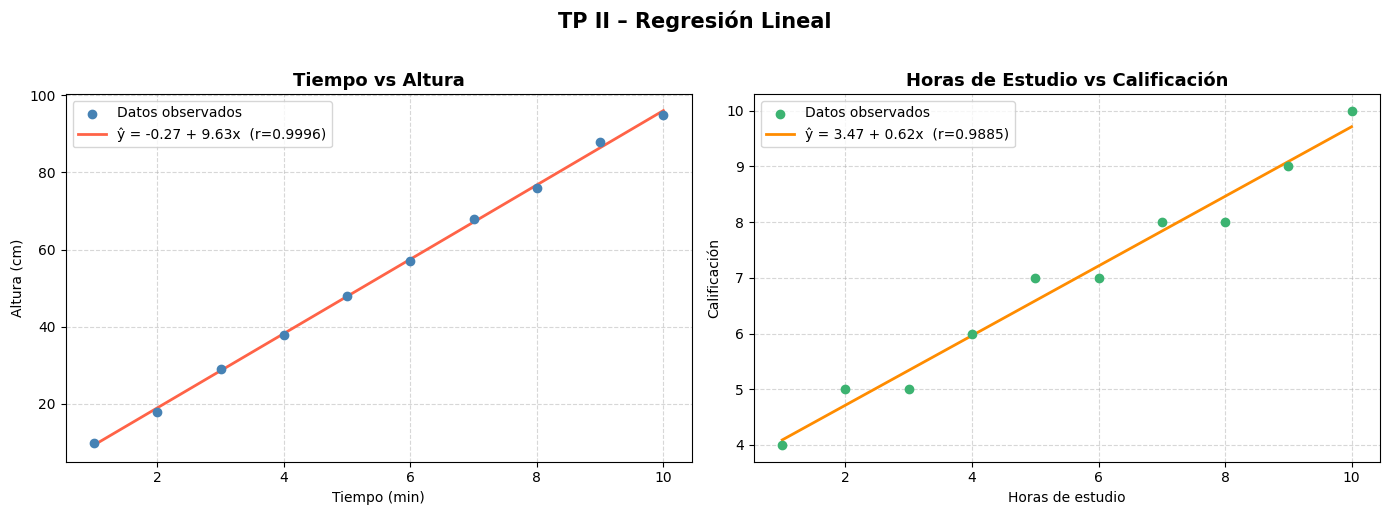


¿Los datos parecen seguir una tendencia lineal?
  Dataset 1 (Tiempo/Altura)     : Sí, la dispersión sigue una línea ascendente.
  Dataset 2 (Horas/Calificación): Sí, a mayor cantidad de horas, mayor calificación.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tiempo y Altura
ax1 = axes[0]
x_line1 = np.linspace(tiempo.min(), tiempo.max(), 100)
y_line1 = a1 + b1 * x_line1

ax1.scatter(tiempo, altura, color='steelblue', zorder=5, label='Datos observados')
ax1.plot(x_line1, y_line1, color='tomato', linewidth=2,
         label=f'ŷ = {a1:.2f} + {b1:.2f}x  (r={r1:.4f})')
ax1.set_title('Tiempo vs Altura', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tiempo (min)')
ax1.set_ylabel('Altura (cm)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

#  Gráfico 2: Horas y Calificación
ax2 = axes[1]
x_line2 = np.linspace(horas.min(), horas.max(), 100)
y_line2 = a2 + b2 * x_line2

ax2.scatter(horas, calificacion, color='mediumseagreen', zorder=5, label='Datos observados')
ax2.plot(x_line2, y_line2, color='darkorange', linewidth=2,
         label=f'ŷ = {a2:.2f} + {b2:.2f}x  (r={r2:.4f})')
ax2.set_title('Horas de Estudio vs Calificación', fontsize=13, fontweight='bold')
ax2.set_xlabel('Horas de estudio')
ax2.set_ylabel('Calificación')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('TP II – Regresión Lineal', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n¿Los datos parecen seguir una tendencia lineal?')
print('  Dataset 1 (Tiempo/Altura)     : Sí, la dispersión sigue una línea ascendente.')
print('  Dataset 2 (Horas/Calificación): Sí, a mayor cantidad de horas, mayor calificación.')